## Contents

- Get familiar with most important types of plots for data visualization.
- Learn how to generate such pluts with the **seaborn** Python package.
- **seaborn**: bulit on top of **matplotlib**, which in turn is built on top of **NumPy**.
- Very well integrated with **pandas** data frames and easier to use than matplotlib (at the price of reduced fine-grained control).

In [8]:
import pandas
import scipy
import itertools as itt
import matplotlib.pyplot as plt
import seaborn as sns

# The matplotlib object hierarchy

- Level 1: Figure (always exactly one)
- Level 2: Axes (= figure panel, possibly more than one).
- Level 3: x- and y-axis, title, etc.


<img src="https://files.realpython.com/media/fig_map.bc8c7cabd823.png">

## Generating a figure with 2 x 3 axes

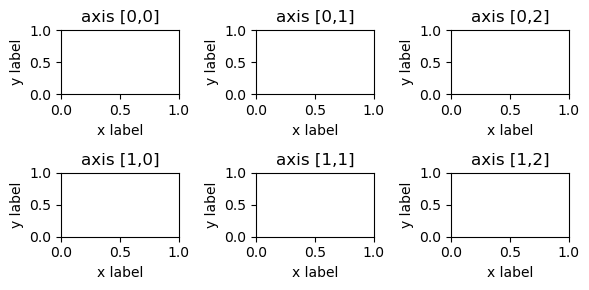

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(6, 3))
for i, j in itt.product([0,1],[0,1,2]):
    axes[i,j].set_title(f'axis [{i},{j}]')
    axes[i,j].set_ylabel('y label')
    axes[i,j].set_xlabel('x label')
fig.tight_layout()

## Generating a figure with a custom layout

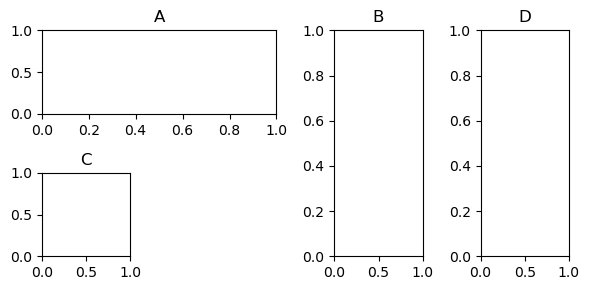

In [3]:
mosaic = [
    ['A', 'A', 'B','D'],
    ['C', '.', 'B','D']
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(6, 3))
for label in ['A', 'B', 'C', 'D']:
    axes[label].set_title(label)
fig.tight_layout()

## Saving a figure to a file

In [6]:
fig.savefig('output/example-figure.png') # Save as PNG (pixel graphic)
fig.savefig('output/example-figure.pdf') # Save as PDF (vector graphic)

## Load Data To Construct Seaborn Plots

- Seaborn naturally interfaces with pandas data frames
- Here: datasets from the seaborn package

In [3]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [7]:
df = sns.load_dataset('car_crashes')
display(df.head())

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


# Visualizing individual numeric values

## Bar plots

<img src="input/bar_chart.png" width="400">

- **Each bar** represents one numeric value.
- Represented numeric values can be individual measurements or summary statistics such as means or medians.
- **Error bars** represent estimated uncertainty of the numeric value.
- Uncertainty estimates can, e.g., be confidence intervals or standard deviations.

## Example: fractions of Titanic survivors split by class and gender

<Axes: xlabel='sex', ylabel='survived'>

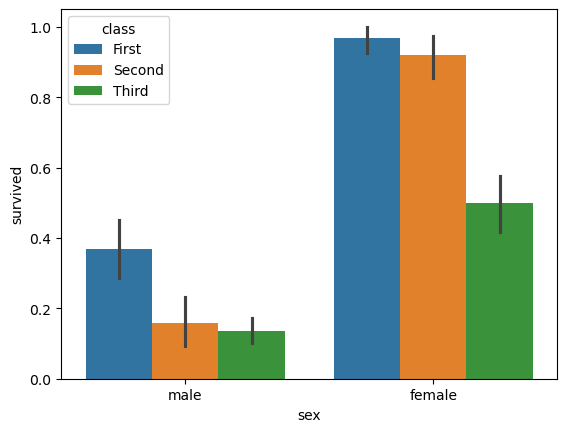

In [59]:
titanic = sns.load_dataset('titanic')
sns.barplot(x = 'sex', y = 'survived', hue = 'class', data = titanic, errorbar='ci')

# Visualizing distributions of individual variables

## Histograms

<img src="input/histogram.png" width="600">

- A histogram **represents the value frequency distribution** of a variable using bars.
- The $x$-axis represents data bins (intervals), the $y$-axis represents the frequency of observations in each bin.
- The **height** of each bar corresponds to the number of data points within that bin.
- Histograms help to visually identify patterns such as skewness, modality, and dispersion in a dataset.
- Can also be used to visualize discrete distributions (no binning necessary).

## Example: plot petal length distribution in iris dataset, colored by species (I)

In [9]:
df = sns.load_dataset('iris')
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Example: plot petal length distribution in iris dataset, colored by species (II)

<Axes: xlabel='petal_length', ylabel='Count'>

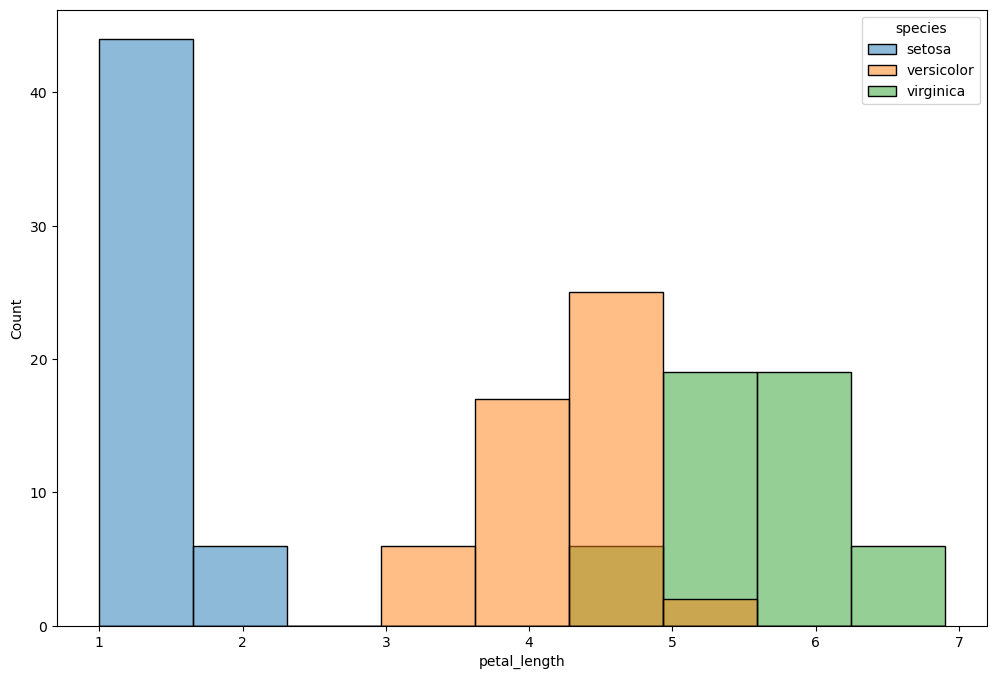

In [12]:
sns.histplot(data=df, x='petal_length', hue='species')

## Gaussian kernel density estimate (KDE) plots

<img src="input/kde_plot.png" width="400">

- A Gaussian kernel density estimate (KDE) plot is a **smoothed, continuous version of a histogram**.
- KDE assigns probability density function (PDF) $f_N(x_i,h^2)$ of normal distribution $N(x_i,h^2)$ to each data point $x_i$.
- Plot mixture $f$ of these individual PDFs:
$$
f(x)=\frac{1}{nh}\sum_{i=1}^nf_{N(x_i,h^2)}(x)=\frac{1}{nh}\sum_{i=1}^n\frac{1}{\sqrt{2\pi}}e^{-\frac{(x-x_i)^2}{2h^2}}
$$
- $N(x_i,h^2)$ is centered at the data point $x_i$ and has standard deviation $h$ (**"bandwidth" hyper-parameter**). 
- **Too small $h$:** noisy plot, under-smoothing. 
- **Too large $h$:** small trends in data ignored, over-smoothing.

## Example: petal length distribution as KDE plots with different bandwidths

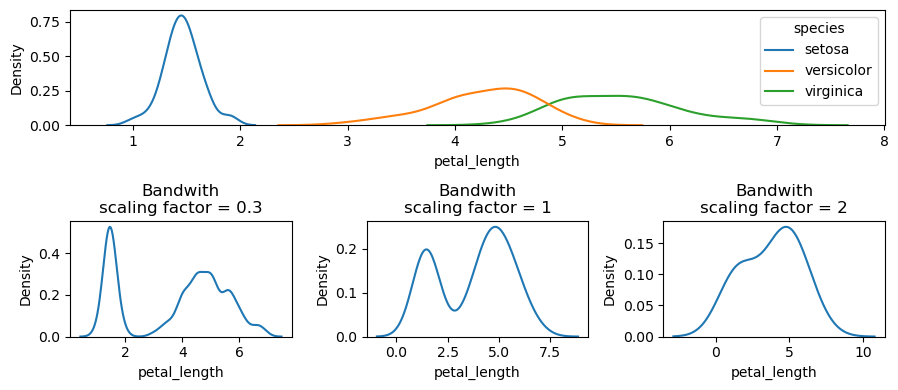

In [13]:
mosaic = [
    [3,3,3],
    [0,1,2]]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(9, 4))
sns.kdeplot(data=df, x='petal_length', hue='species', ax=axes[3])
bws = [0.3,1,2]
for i, bw in enumerate(bws):
    sns.kdeplot(data=df, x='petal_length', bw_adjust=bws[i], ax=axes[i])
    axes[i].set_title(f'Bandwith\nscaling factor = {bw}')
fig.tight_layout()

## Box plots

<img src="input/boxplot.png" width="600">

- The **axis of the figure** (can be horizontal or vertical) represents the data distribution.
- The **box** spans the interquartile range (IQR): from the first quartile (Q1) to the third quartile (Q3).
- The **thick line inside the box** marks the median of the data.
- **Whiskers otpion 1:** The whiskers extend to the minimum and maximum values within 1.5 times the IQR. Any points beyond the whiskers are considered outliers and are marked separately.
- **Whiskers otpion 2:** The whiskers extend to the minimum and maximum values of the data. No points beyond the whiskers.

## Example: a simple box plot

<Axes: xlabel='day', ylabel='total_bill'>

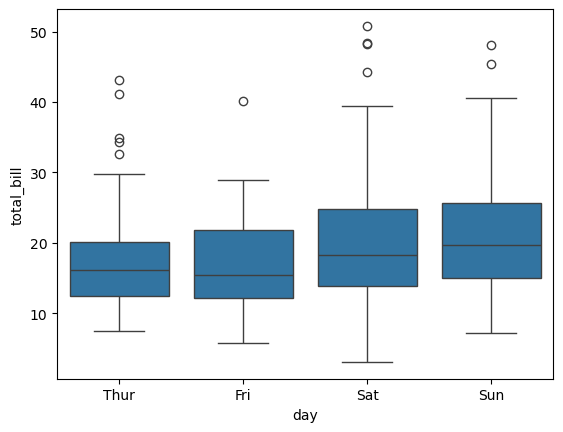

In [9]:
tips = sns.load_dataset("tips")
sns.boxplot(x="day", y="total_bill", data=tips)

## Violin plots

<img src="input/violin_plots.png" width="400">

- **Box plot or quartile lines inside:** visualization of the median, quartiles, and possible outliers.
- **KDE plot around the box plot:** visualization of data density.
- **Example:** Violin plots visualize bimodality of the *Process A* data, which is not shown by the box plots alone.
- **Note:** KDE and violin plots can be misleading when Gaussian mixtures go beyond the range of the data or even the domain of the variable.
- **Solution:** Cut KDE plots at minimum and maximum values.

## Example: a box plot and a violin plot of the same data

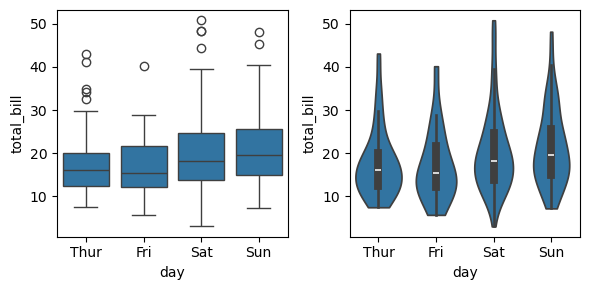

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
sns.boxplot(x="day", y="total_bill", data=tips, ax=axes[0])
sns.violinplot(x="day", y="total_bill", data=tips, cut=0, ax=axes[1])
fig.tight_layout()

## Exercise 1

Execute the code bellow to create a new dataframe that has shop's visit time and days of visits. Then, make a simple boxplot where you show visit times for the 7 days of the week. Make a violin plot with the same setting. Which one is more informative? Why?

In [60]:
import numpy as np
import pandas as pd
mon = list(np.random.normal(9,1,20)) + list(np.random.normal(18,1,20))
tue = list(np.random.normal(8,1,20)) + list(np.random.normal(19,2,20))
wed = list(np.random.normal(18,2,40))
restaurant = pd.DataFrame([mon+tue+wed,["Monday"]*len(mon)+["Tuesday"]*len(tue)+["Wednesday"]*len(wed)])
restaurant = restaurant.T
restaurant.columns = ["visit_time", "day"]
restaurant["visit_time"] = restaurant["visit_time"].astype('float')
restaurant.head()

,visit_time,day
0,9.000548,Monday
1,8.787832,Monday
2,8.892694,Monday
3,10.035697,Monday
4,8.250160,Monday


# Visualizing relationships (between $\geq 2$ variables or samples and variables)

## 2D scatter plots {.nostretch}

<img src="input/correlation_regression.png" width="400">

- Helps to **identify trends, correlations, or outliers** between the two variables.
- **Points that are close together:** indicative of strong relationship. **Spread-out points:** suggest weaker relationships.
- **Annotate with linear regression model:** slope $\beta$ quantifies effect size of linear relationship.
- **Annotate with Pearson's correlation coefficient $r$:** quantifies strength of linear relationship.
- **Strength $\neq$ effect size:** Strength $r=(\beta\sigma_\mathbf{x})/\sigma_\mathbf{y}$ positively proportional to $\beta$ and standard deviation $\sigma_\mathbf{x}$ of $\mathbf{x}$ but negatively proportional to standard deviation $\sigma_\mathbf{y}$ of $\mathbf{y}$

## Example: 2D scatter plots with and without linear models

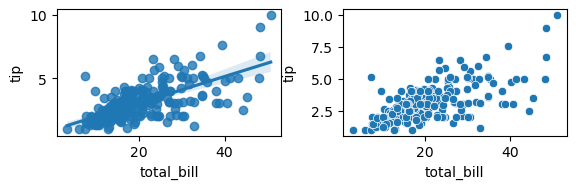

In [54]:
fig, axes = plt.subplots(1, 2, figsize = (6,2))
sns.regplot(data=tips, x="total_bill", y="tip", ax=axes[0])
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=axes[1])
fig.tight_layout()

## Exercise 2

- Load the dataset named **diamonds**. Make a relplot that shows the relationship between price and carat. Separate the results by a quality of a cut.
- The simple linear regression model used above is very simple to fit, however, it is not appropriate for some kinds of datasets. The Anscombe’s quartet dataset shows a few examples where simple linear regression provides an identical estimate of a relationship where simple visual inspection clearly shows differences. Load the **anscombe** dataset then slice it by the variable "dataset", and find an appropreate fit for dataset I, II and III. **Hint:** Utilize the `order` parameter of `sns.regplot` to estimate polynomial regression and the `robust` parameter to de-weight outliers.

## Heat maps

<img src="input/heatmap_1.png" width="300"> <img src="input/heatmap_2.png" width="300">

- 2D graphical representation of data where **values are represented by colors**.
- **Sample $\times$ variable heat maps:** Each cell represents the value of a variable for a specific sample.
- **Variable $\times$ variables heat maps:** Each cell represents a measure of correlation between two variables across several (or all) samples.

## Example: numbers of passengers per months over 12 years (I)

In [14]:
flights=sns.load_dataset('flights')
display(flights.head())

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Example: numbers of passengers per months over 12 years (II)

In [15]:
flights = flights.pivot(index='month', columns='year', values='passengers')
flights.head()

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472


## Example: numbers of passengers per months over 12 years (III)

<Axes: xlabel='year', ylabel='month'>

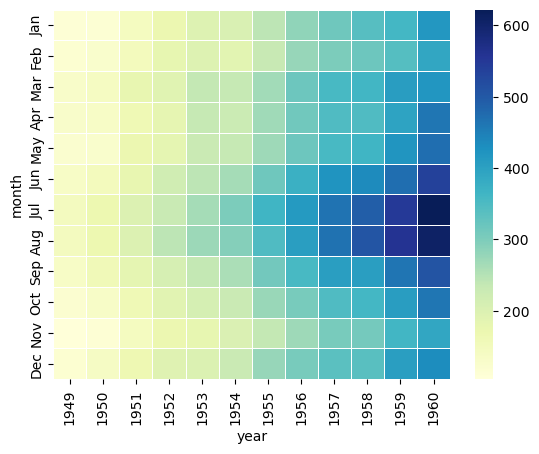

In [70]:
sns.heatmap(flights,linewidths=.5, cmap="YlGnBu")

## Example: visualizing correlations between car accident properties (I)

In [21]:
car_crashes = sns.load_dataset("car_crashes")
display(car_crashes.head())

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## Example: visualizing correlations between car accident properties (II)

In [22]:
car_crashes = car_crashes.drop('abbrev', axis=1)
corr=car_crashes.corr()
display(corr)

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
total,1.000000,0.611548,0.852613,0.827560,0.956179,-0.199702,-0.036011
speeding,0.611548,1.000000,0.669719,0.588010,0.571976,-0.077675,-0.065928
alcohol,0.852613,0.669719,1.000000,0.732816,0.783520,-0.170612,-0.112547
not_distracted,0.827560,0.588010,0.732816,1.000000,0.747307,-0.174856,-0.075970
no_previous,0.956179,0.571976,0.783520,0.747307,1.000000,-0.156895,-0.006359
ins_premium,-0.199702,-0.077675,-0.170612,-0.174856,-0.156895,1.000000,0.623116
ins_losses,-0.036011,-0.065928,-0.112547,-0.075970,-0.006359,0.623116,1.000000


## Example: visualizing correlations between car accident properties (III)

<Axes: >

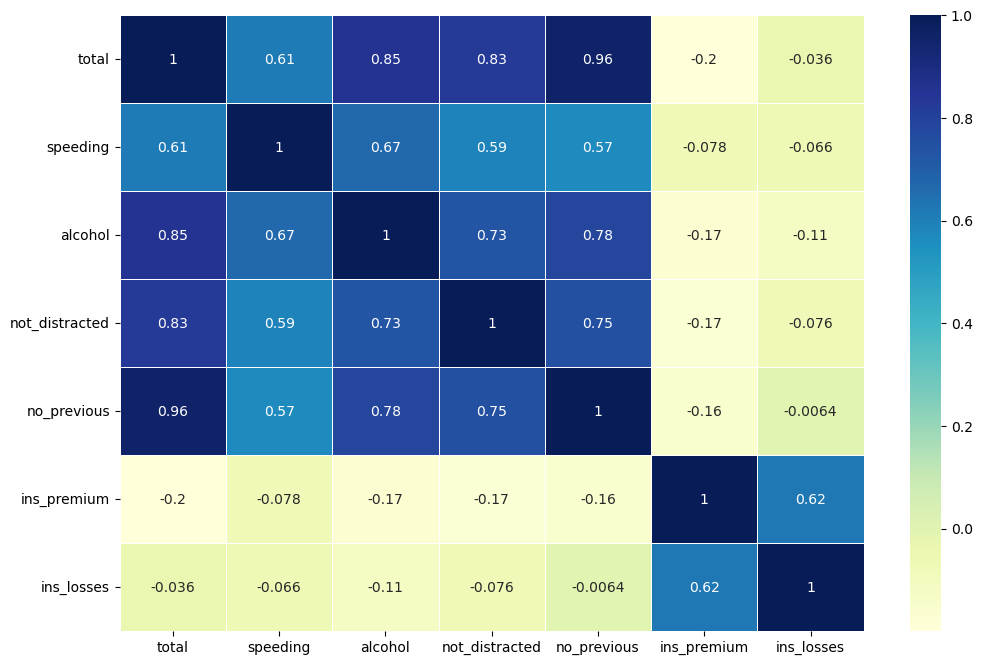

In [27]:
sns.heatmap(corr, linewidths=.5, cmap="YlGnBu", annot=True)

## Exercise 3

Create a heatmap of flights happened between 1955 and 1960 (including both ends, use numpy/pandas for this). Play around with the parameters of `sns.heatmap` to change the look of the plot. Save the plot as a PDF file.

# Solutions for exercises

## Solution for Exercise 1

In [28]:
import numpy as np
import pandas as pd
mon = list(np.random.normal(9,1,20)) + list(np.random.normal(18,1,20))
tue = list(np.random.normal(8,1,20)) + list(np.random.normal(19,2,20))
wed = list(np.random.normal(18,2,40))
restaurant = pd.DataFrame([mon+tue+wed,["Monday"]*len(mon)+["Tuesday"]*len(tue)+["Wednesday"]*len(wed)])
restaurant = restaurant.T
restaurant.columns = ["visit_time", "day"]
restaurant["visit_time"] = restaurant["visit_time"].astype('float')
restaurant.head()

,visit_time,day
0,9.341641,Monday
1,8.215534,Monday
2,9.257650,Monday
3,10.289157,Monday
4,7.230076,Monday


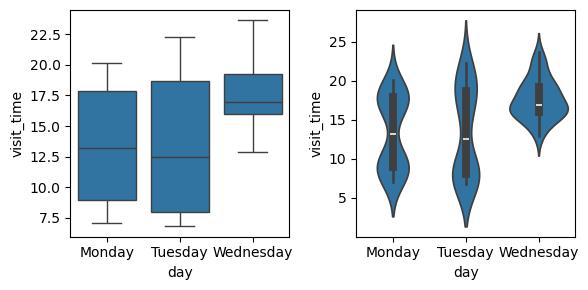

In [32]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6,3))
sns.boxplot(data=restaurant, x='day', y='visit_time', ax=axes[0])
sns.violinplot(data=restaurant, x='day', y='visit_time', ax=axes[1])
fig.tight_layout()

## Solution for Exercise 2

In [34]:
diamonds = sns.load_dataset("diamonds")
display(diamonds.head())
cuts = list(set(diamonds.cut))

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


['Good', 'Ideal', 'Fair', 'Very Good', 'Premium']

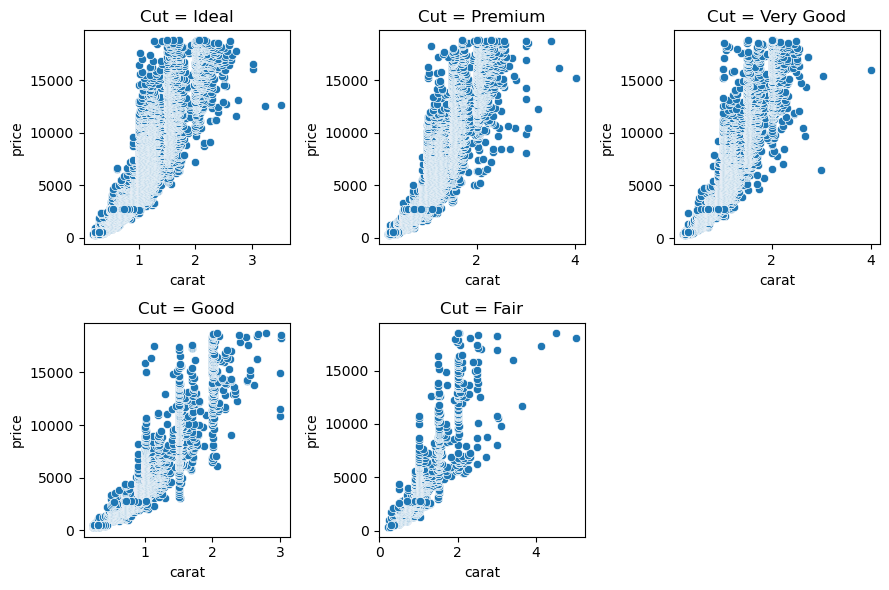

In [41]:
mosaic = [['Ideal', 'Premium', 'Very Good'],
          ['Good', 'Fair', '.']]
fig, axes = plt.subplot_mosaic(mosaic=mosaic, figsize=(9,6))
for cut in cuts:
    sns.scatterplot(data=diamonds[diamonds.cut == cut], x = 'carat', y='price', ax=axes[cut])
    axes[cut].set_title(f'Cut = {cut}')
fig.tight_layout()

In [55]:
anscombe = sns.load_dataset("anscombe")
display(anscombe.head())

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [ ]:
sns.lmplot(x="x", y="y", col='dataset', col_wrap=2, data=anscombe, height=3, order=2, 
           ci=None, scatter_kws={"s": 80, 'color':'red'}, line_kws={'color':'green'})

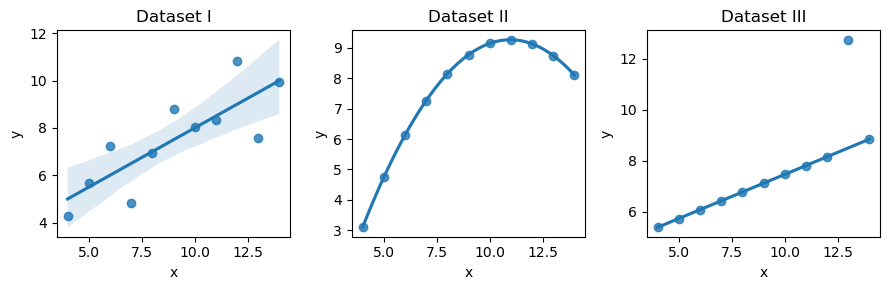

In [66]:
mosaic = [['I', 'II', 'III']]
fig, axes = plt.subplot_mosaic(mosaic=mosaic, figsize=(9,3))
sns.regplot(data=anscombe[anscombe.dataset == 'I'], x = 'x', y='y', ax=axes['I'])
sns.regplot(data=anscombe[anscombe.dataset == 'II'], x = 'x', y='y', ax=axes['II'], order=2)
sns.regplot(data=anscombe[anscombe.dataset == 'III'], x = 'x', y='y', ax=axes['III'], robust=True, ci=False)
for dataset in ['I', 'II', 'III']:
    axes[dataset].set_title(f'Dataset {dataset}')
fig.tight_layout()

## Solution for Exercise 3

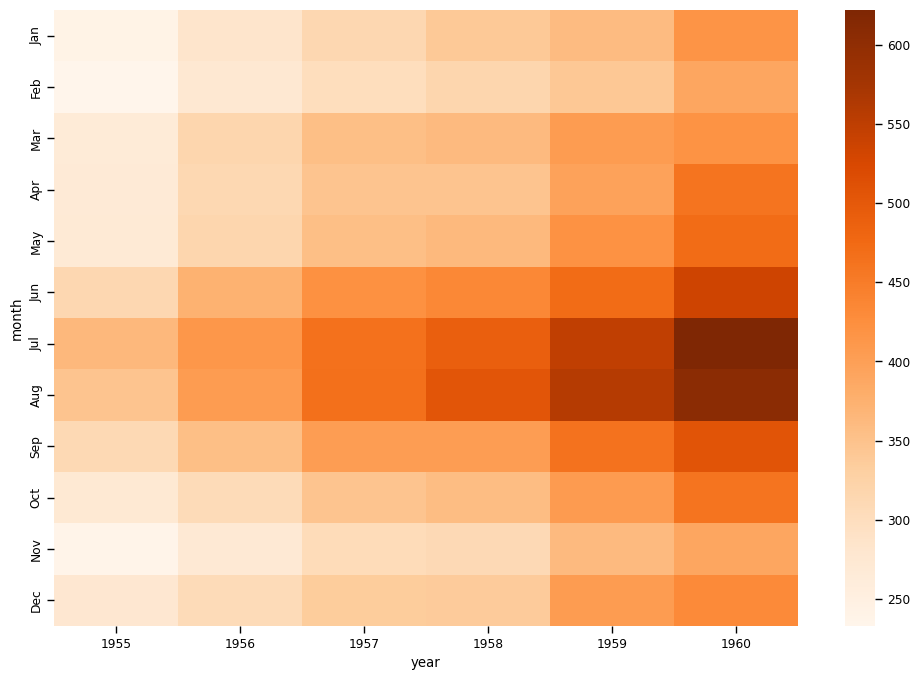

In [68]:
sns.set_context("paper")
p = sns.heatmap(flights[np.arange(1955,1961)],cmap = "Oranges" )
fig = p.get_figure()
fig.savefig("output/flights.pdf")